<a href="https://colab.research.google.com/github/arturodeleon19/Uncovering-Healthcare-Data-Insights/blob/main/Uncovering_Healthcare_Data_Insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
zip_path = '/content/Health Dataset by Prasad Patil.zip'
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall()

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import cuml
cuml.accel.install()  # Activates GPU acceleration for supported scikit-learn components

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv('/content/healthcare_dataset.csv')

df.head()


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [3]:
conn = sqlite3.connect('my_database.db')

df.to_sql('my_table', conn, if_exists='replace', index=False)


55500

In [4]:
query = """
SELECT
    "Medical Condition",
    "Insurance Provider",
    ROUND(AVG("Billing Amount"), 2) AS average_billing
FROM
    my_table
GROUP BY
    "Medical Condition",
    "Insurance Provider"
ORDER BY
    "Medical Condition" ASC,
    average_billing DESC;
"""

# Execute the query and view the breakdown
comparison_df = pd.read_sql_query(query, conn)
comparison_df

,Medical Condition,Insurance Provider,average_billing
0,Arthritis,Blue Cross,25792.79
1,Arthritis,UnitedHealthcare,25627.49
2,Arthritis,Aetna,25478.95
3,Arthritis,Cigna,25318.17
4,Arthritis,Medicare,25272.08
5,Asthma,Aetna,25846.96
6,Asthma,UnitedHealthcare,25819.63
7,Asthma,Medicare,25765.96
8,Asthma,Cigna,25610.47
9,Asthma,Blue Cross,25141.78


### Exploratory Data Analysis: Key Insights & Findings

> **Overview:** Summary of aggregate billing patterns analyzed across medical conditions and insurance providers.

* **Tight Billing Compression:** Average billing amounts are tightly clustered between \$24,857 and \$26,117, showing very low overall variance.
* **Obesity as the Highest Cost Driver:** Obesity consistently commands the highest billing averages across multiple insurance providers, peaking with Cigna at \$26,117.00 and Blue Cross at \$26,100.79.
* **Cancer Exhibiting Lower Averages:** Conversely, Cancer records some of the lowest tier averages in this dataset, bottoming out with UnitedHealthcare at \$24,857.85 and Aetna at \$24,923.41.
* **Minimal Inter-Provider Discrepancy:** Within any single medical condition, the delta between the highest and lowest insurance provider is narrow (typically \$400 to \$600), indicating that insurance type has a minimal impact on average billing in this scope.


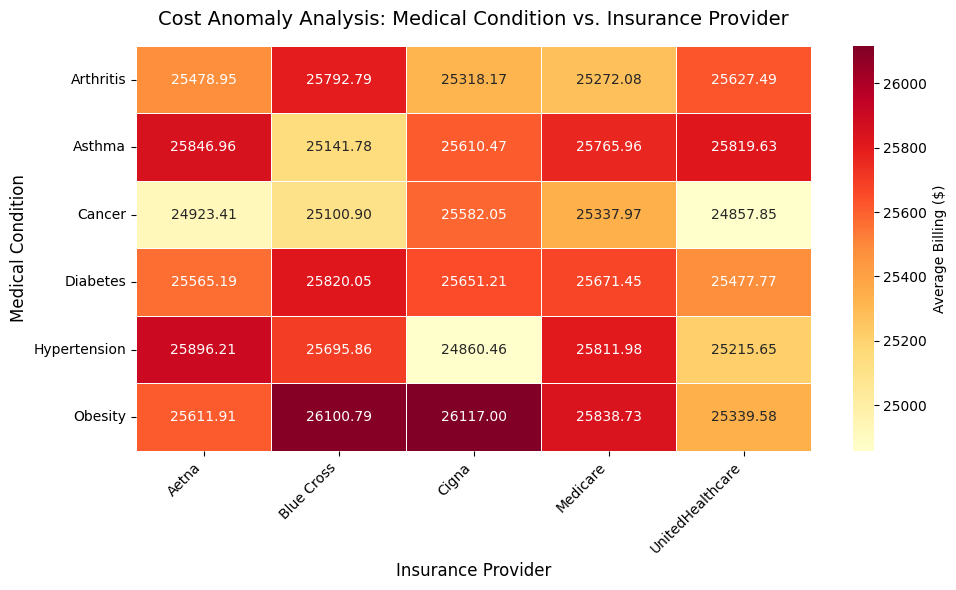

In [5]:
# Ensure inline plotting
%matplotlib inline

# Pivot the data to create a 2D matrix structure

heatmap_data = comparison_df.pivot(
    index='Medical Condition',
    columns='Insurance Provider',
    values='average_billing'
)

# Configure the plot size
plt.figure(figsize=(10, 6))

# Generate the heatmap
sns.heatmap(
    heatmap_data,
    annot=True,            # Displays the dollar values inside each cell
    fmt=".2f",             # Formats numbers to 2 decimal places
    cmap="YlOrRd",         # Yellow-Orange-Red color map (ideal for cost intensity)
    linewidths=0.5,        # Adds clean grid lines between cells
    cbar_kws={'label': 'Average Billing ($)'}
)

# Customize titles and axis labels
plt.title('Cost Anomaly Analysis: Medical Condition vs. Insurance Provider', fontsize=14, pad=15)
plt.xlabel('Insurance Provider', fontsize=12)
plt.ylabel('Medical Condition', fontsize=12)

# Improve label readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Display the visualization
plt.tight_layout()
plt.show()

In [6]:
grid_query = """
SELECT
    "Medical Condition",
    "Admission Type",
    Gender,
    COUNT(*) AS total_patients,
    ROUND(AVG("Billing Amount"), 2) AS average_bill
FROM
    my_table
GROUP BY
    "Medical Condition",
    "Admission Type",
    Gender
ORDER BY
    average_bill DESC;
"""

grid_df = pd.read_sql_query(grid_query, conn)
grid_df.head(10)

,Medical Condition,Admission Type,Gender,total_patients,average_bill
0,Obesity,Emergency,Female,1558,26387.94
1,Asthma,Urgent,Male,1620,26364.35
2,Asthma,Emergency,Male,1471,26315.37
3,Diabetes,Elective,Male,1515,26308.78
4,Cancer,Elective,Male,1592,26127.44
5,Obesity,Urgent,Male,1537,26106.64
6,Arthritis,Emergency,Male,1535,25956.97
7,Obesity,Elective,Male,1504,25930.10
8,Hypertension,Emergency,Male,1496,25765.19
9,Obesity,Urgent,Female,1525,25742.82


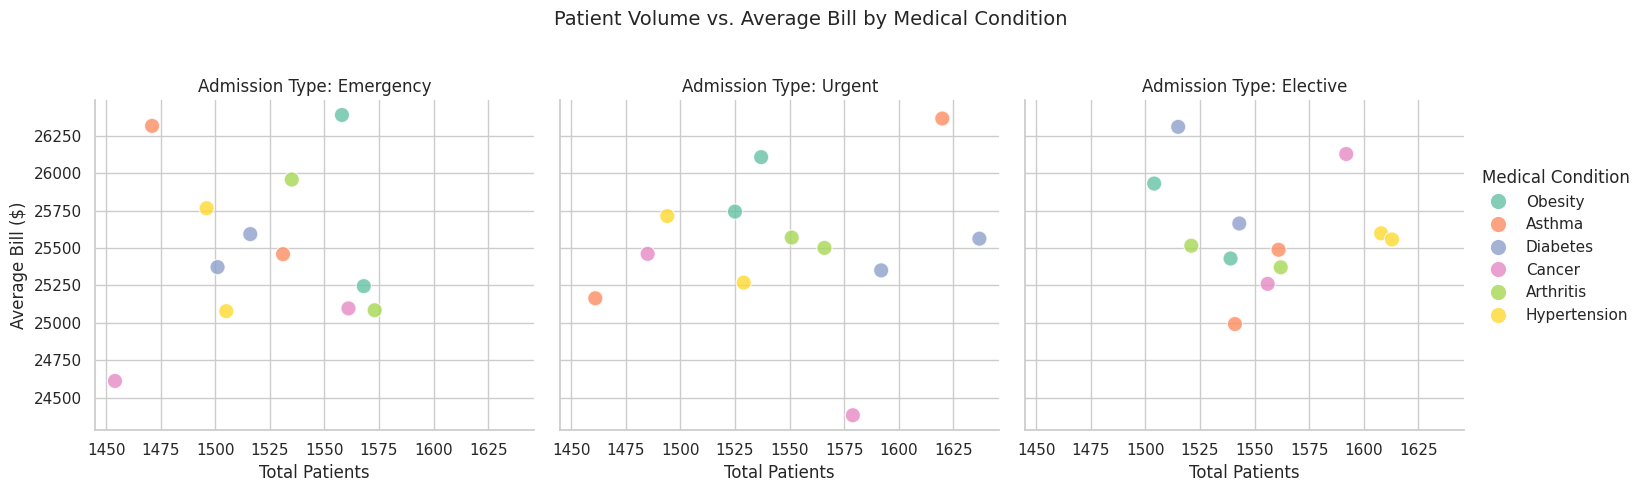

In [7]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Create the faceted scatter plot
g = sns.relplot(
    data=grid_df,
    x="total_patients",
    y="average_bill",
    hue="Medical Condition",
    col="Admission Type",  # Creates separate facets for each admission type
    kind="scatter",
    s=120,  # Size of the markers
    palette="Set2",
    alpha=0.8,
)

# Customize labels and titles for clarity
g.set_axis_labels("Total Patients", "Average Bill ($)")
g.set_titles(col_template="Admission Type: {col_name}")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Patient Volume vs. Average Bill by Medical Condition", fontsize=14)

plt.show()

### Summary of Findings: Patient Volume vs. Average Bill

This faceted scatter plot visualizes the relationship between **Total Patients** (X-axis) and **Average Bill ($)** (Y-axis) broken down by **Admission Type** (Emergency, Urgent, and Elective) and colored by **Medical Condition**.

* **Emergency Admissions:** Features a wide distribution of costs, with Asthma and Obesity showing higher average bills, while Cancer records the lowest average bill in this category.
* **Urgent Admissions:** Asthma reaches the highest average bill, whereas Cancer drops significantly in average cost compared to the other medical conditions.
* **Elective Admissions:** Diabetes and Cancer show higher average bills relative to others, while patient counts across most conditions remain tightly clustered between 1,500 and 1,625.
* **Overall Trend:** Patient volume stays relatively uniform across conditions, whereas the average bill fluctuates more noticeably based on the specific interaction between admission type and medical condition.

In [8]:
grid_query = """
SELECT
  "Insurance Provider",
  "Medical Condition",
   AVG("Billing Amount") as avg_bill
FROM
  my_table
WHERE
  "Admission Type" = "Emergency"
GROUP BY
  "Insurance Provider",
  "Medical Condition"
HAVING
  AVG("Billing Amount") > 25000;
"""
grid_High_Cost = pd.read_sql_query(grid_query, conn)
grid_High_Cost

,Insurance Provider,Medical Condition,avg_bill
0,Aetna,Arthritis,25276.471963
1,Aetna,Asthma,25666.396083
2,Aetna,Diabetes,25247.726378
3,Aetna,Hypertension,25592.138486
4,Aetna,Obesity,25828.320716
5,Blue Cross,Arthritis,26090.349258
6,Blue Cross,Asthma,25679.567275
7,Blue Cross,Cancer,25228.728991
8,Blue Cross,Diabetes,25074.493967
9,Blue Cross,Hypertension,25204.362866


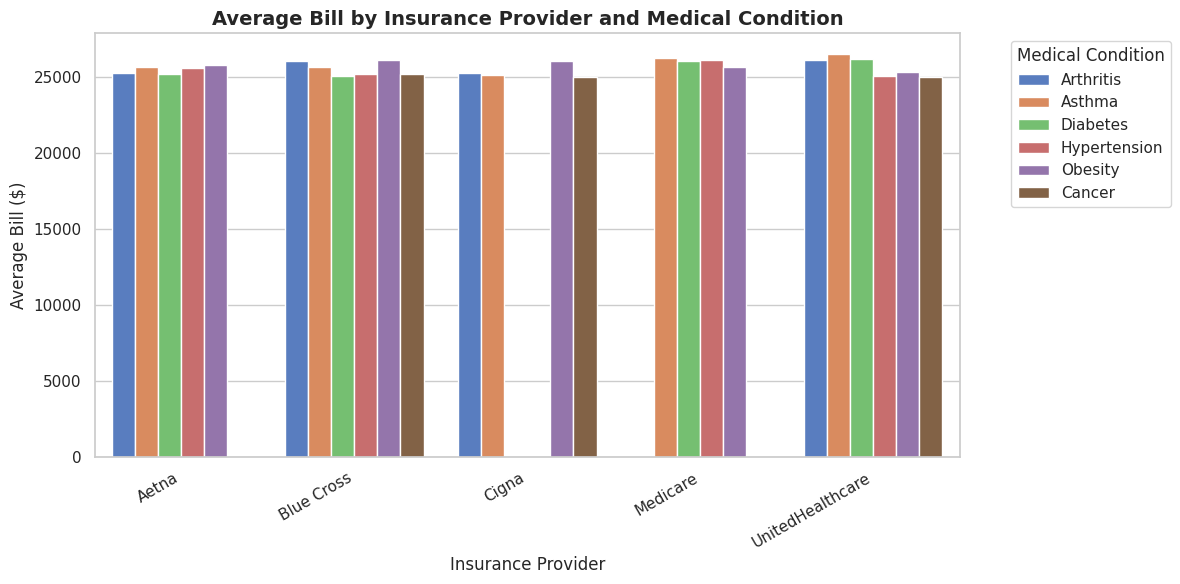

In [9]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Set up the figure size
plt.figure(figsize=(12, 6))

# Create the grouped (clustered) bar chart
ax = sns.barplot(
    data=grid_High_Cost,
    x="Insurance Provider",
    y="avg_bill",
    hue="Medical Condition",
    palette="muted"  # Color palette for the medical conditions
)

# Customize titles and labels
plt.title("Average Bill by Insurance Provider and Medical Condition", fontsize=14, fontweight="bold")
plt.xlabel("Insurance Provider", fontsize=12)
plt.ylabel("Average Bill ($)", fontsize=12)

# Rotate X-axis labels slightly for better readability
plt.xticks(rotation=30, ha="right")

# Move the legend outside the plot area so it doesn't overlap the bars
plt.legend(title="Medical Condition", bbox_to_anchor=(1.05, 1), loc="upper left")

# Adjust layout to fit everything cleanly
plt.tight_layout()

# Display the plot
plt.show()

### Key Insights: Average Bill by Insurance Provider and Medical Condition

* **Consistent Cost Baseline:** Across all insurance providers and medical conditions, the average bill remains remarkably uniform, hovering tightly within the $25,000 to $26,500 range.
* **Provider Highs:** UnitedHealthcare and Medicare feature some of the highest average billing peaks across multiple medical categories.
* **Missing Data Points:** Certain providers, such as Cigna and Medicare, lack data bars for specific medical conditions, indicating gaps or selective coverage in the subset.
* **Condition Stability:** Conditions like Obesity and Asthma appear consistently across almost all major insurance providers with only minor cost fluctuations.

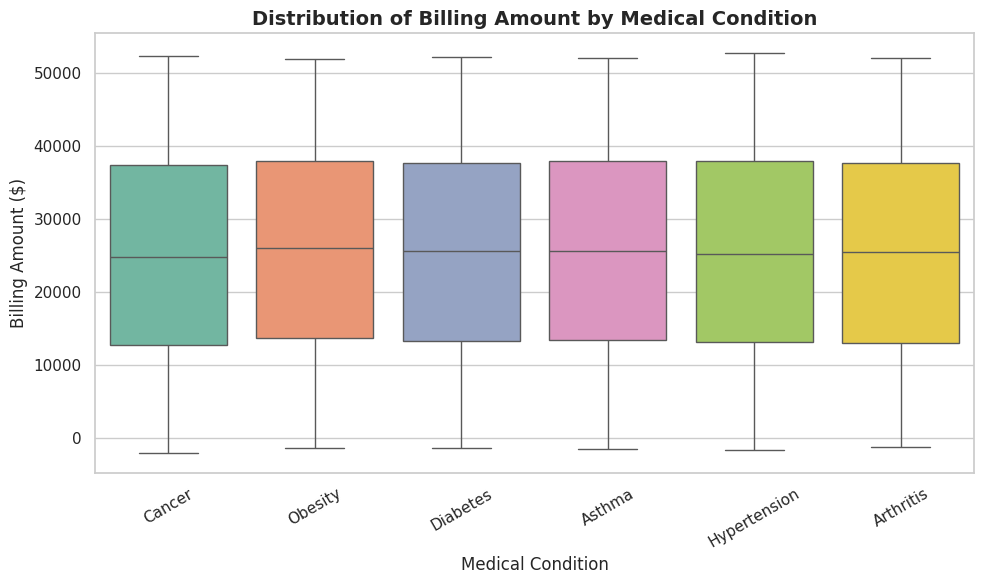

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Medical Condition", y="Billing Amount", palette="Set2", hue = "Medical Condition", legend=False)

plt.title("Distribution of Billing Amount by Medical Condition", fontsize=14, fontweight="bold")
plt.xlabel("Medical Condition", fontsize=12)
plt.ylabel("Billing Amount ($)", fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Summary of Findings: Distribution of Billing Amount by Medical Condition

This box plot visualizes the distribution, median, and spread of billing amounts across different medical conditions.

* **Uniform Median Costs:** The median billing amount (indicated by the horizontal line inside each box) is remarkably consistent across all categories, hovering right around $25,000.

* **Consistent Interquartile Range (IQR):** The middle 50% of billing amounts (represented by the boxes) spans similarly for every condition, generally running from roughly 13,000 to 38,000.
* **Equal Range Limits:** The minimum billing amounts start near zero, while the maximum values cap out uniformly at just over $50,000 across all medical conditions.
* **Key Takeaway:** The billing amount distribution shows a high degree of homogeneity, indicating that individual medical conditions do not create distinct cost tiers in this dataset.

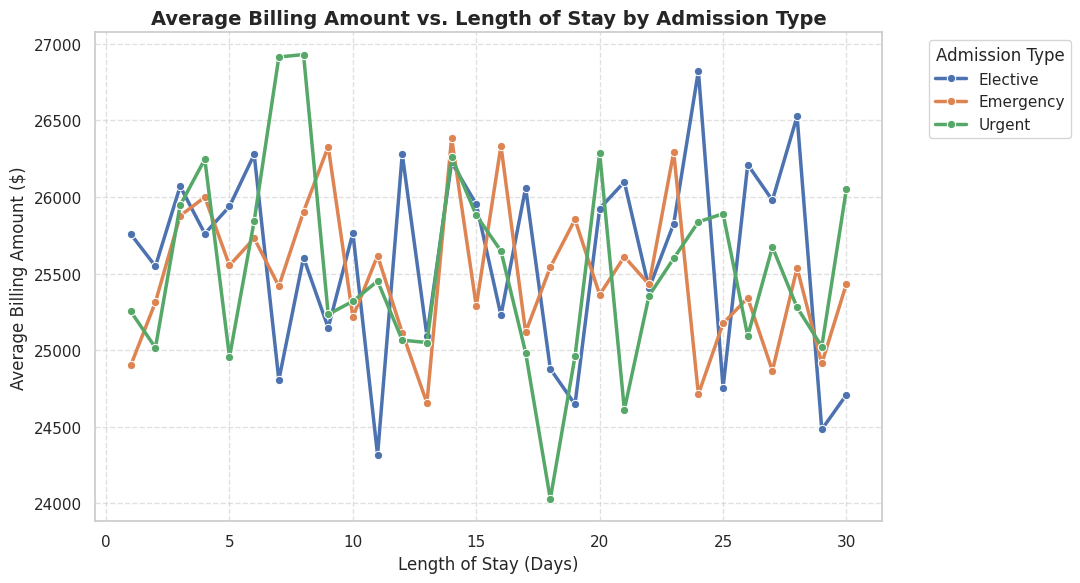

In [11]:
# Convert date columns to datetime objects if they aren't already
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

# Calculate Length of Stay
df['Length_of_Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

# Group data by Length of Stay and Admission Type to find the average bill
agg_df = df.groupby(["Length_of_Stay", "Admission Type"])["Billing Amount"].mean().reset_index()

plt.figure(figsize=(11, 6))
sns.lineplot(
    data=agg_df,
    x="Length_of_Stay",
    y="Billing Amount",
    hue="Admission Type",
    marker="o",
    linewidth=2.5
)

plt.title("Average Billing Amount vs. Length of Stay by Admission Type", fontsize=14, fontweight="bold")
plt.xlabel("Length of Stay (Days)", fontsize=12)
plt.ylabel("Average Billing Amount ($)", fontsize=12)
plt.legend(title="Admission Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Summary of Findings: Average Billing Amount vs. Length of Stay by Admission Type

This line plot illustrates the trajectory of the **Average Billing Amount ($)** across different **Length of Stay (Days)** values, categorized by **Admission Type** (Elective, Emergency, and Urgent).

* **Absence of Direct Correlation:** There is no clear linear relationship indicating that a longer hospital stay results in a higher average billing amount; the trend lines remain relatively flat overall.

* **Bounded Cost Range:** Across all three admission types, the average bills oscillate within a stable and narrow financial band, primarily fluctuating between 24,000 and 27,000.

* **Day-to-Day Volatility:** The lines exhibit high daily fluctuation rather than a smooth pattern, with specific outliers such as an Urgent admission drop near 18 days (hitting a low near $24,000) and an Elective peak around 24 days.

* **Key Takeaway:** The length of stay does not appear to heavily drive or dictate the average billing amount in this dataset, pointing toward uniform or flat-rate pricing structures.

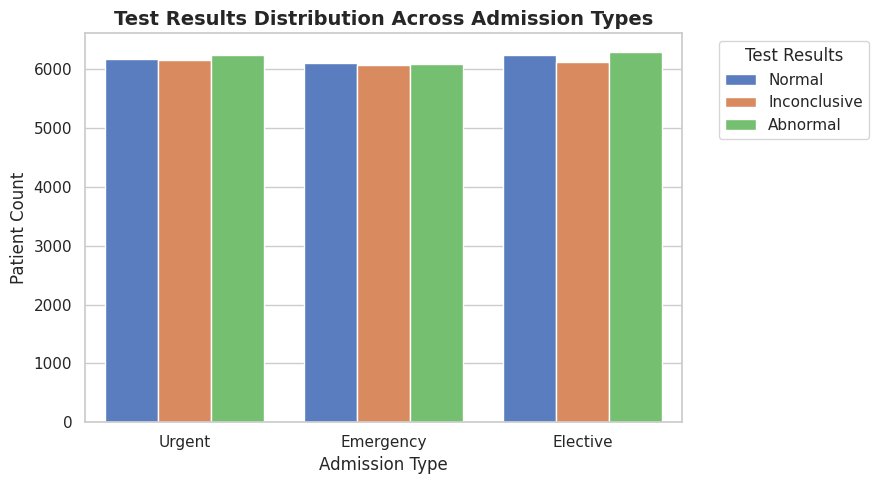

In [12]:
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df,
    x="Admission Type",
    hue="Test Results",
    palette="muted"
)

plt.title("Test Results Distribution Across Admission Types", fontsize=14, fontweight="bold")
plt.xlabel("Admission Type", fontsize=12)
plt.ylabel("Patient Count", fontsize=12)
plt.legend(title="Test Results", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Summary of Findings: Test Results Distribution Across Admission Types

This grouped bar chart illustrates the count of patient test results (**Normal**, **Inconclusive**, and **Abnormal**) categorized by **Admission Type** (**Urgent**, **Emergency**, and **Elective**).

* **Uniform Patient Volume:** The overall patient volume is evenly split across all three admission types (Urgent, Emergency, and Elective), with each category totaling roughly 18,000 patients.
* **Consistent Test Outcome Splits:** Within each admission type, the individual test results are distributed evenly, with Normal, Inconclusive, and Abnormal outcomes each hovering closely around the 6,000 patient mark.
* **Minor Variations:** **Abnormal** test results show a marginally higher patient count across all admission types, while **Inconclusive** results record the lowest, though the variance overall is very small.
* **Key Takeaway:** There is no noticeable correlation or dependency between how a patient is admitted (Urgent, Emergency, or Elective) and the distribution of their test outcomes; results remain remarkably uniform.

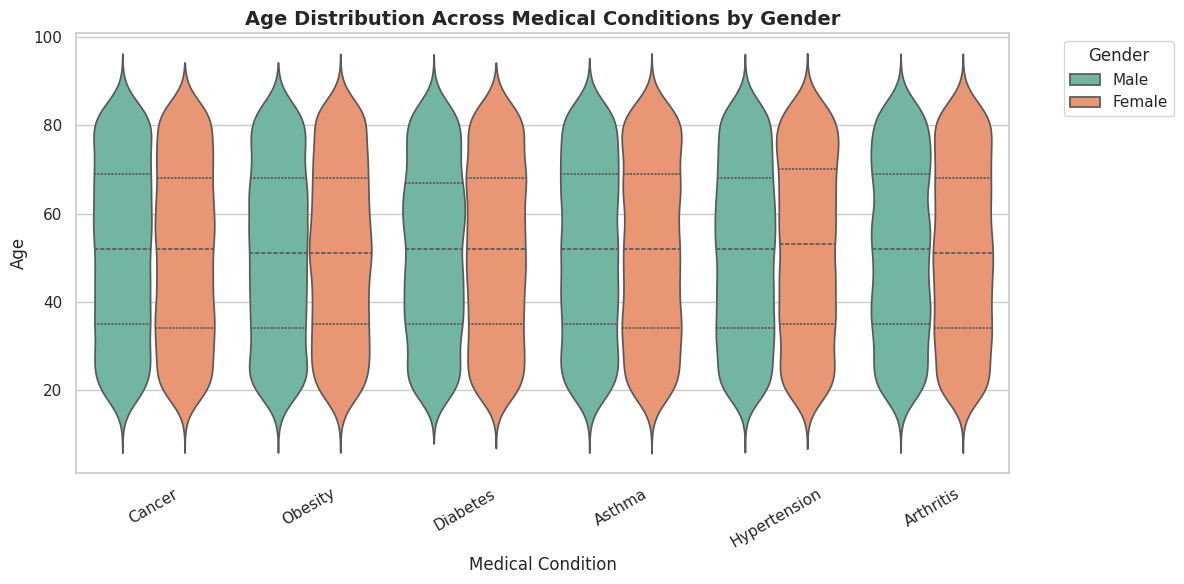

In [16]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x="Medical Condition",
    y="Age",
    hue="Gender",
    palette="Set2",
    split=False,  # Set to True if Gender has only 2 unique values to save space
    inner="quart" # Shows quartiles inside the violins
)

plt.title("Age Distribution Across Medical Conditions by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Medical Condition", fontsize=12)
plt.ylabel("Age", fontsize=12)
plt.xticks(rotation=30)
plt.legend(title="Gender", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

### Summary of Findings: Age Distribution Across Medical Conditions by Gender

This violin plot illustrates the distribution, density, and quartile ranges of patient **Age** across various **Medical Conditions**, categorized by **Gender** (Male and Female).

* **Uniform Age Spread:** The age distribution spans broadly from younger patients (around 5 years old) up to elderly patients (nearly 100 years old) across every single medical condition.
* **Consistent Median Ages:** The median age (indicated by the middle dotted line within each violin) remains remarkably steady at approximately 52 years old across all medical conditions for both genders.
* **Mirrored Gender Patterns:** For every medical condition, the male (teal) and female (orange) distribution shapes mirror each other closely, showing no major age divergence or gender-specific demographic skews.
* **Key Takeaway:** Patient age is uniformly distributed across all medical conditions and genders, indicating that these health conditions occur across all age brackets evenly rather than being tied to a specific demographic.

In [14]:
df.dtypes

,0
Name,object
Age,int64
Gender,object
Blood Type,object
Medical Condition,object
Date of Admission,datetime64[ns]
Doctor,object
Hospital,object
Insurance Provider,object
Billing Amount,float64


In [15]:
df_model = df.copy()

# Drop privacy columns AND high-cardinality columns ('Doctor', 'Hospital')
drop_cols = ['Name', 'Doctor', 'Hospital']
for col in drop_cols:
    if col in df_model.columns:
        df_model = df_model.drop(columns=[col])

# Feature Engineering: Length of Stay
if 'Date of Admission' in df_model.columns and 'Discharge Date' in df_model.columns:
    df_model['Date of Admission'] = pd.to_datetime(df_model['Date of Admission'])
    df_model['Discharge Date'] = pd.to_datetime(df_model['Discharge Date'])
    df_model['Length_of_Stay'] = (df_model['Discharge Date'] - df_model['Date of Admission']).dt.days
    df_model = df_model.drop(columns=['Date of Admission', 'Discharge Date'])

# Clear unused memory
gc.collect()

# Define Features (X) and Target (y) -> Target is 'Test Results'
X = df_model.drop(columns=['Test Results'])
y = df_model['Test Results']

# Delete the dataframe copy to free up RAM
del df_model
gc.collect()

# Standard 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Explicitly define categorical columns
categorical_cols = [
    'Gender', 'Blood Type', 'Medical Condition',
    'Insurance Provider', 'Admission Type', 'Medication'
]
categorical_cols = [col for col in categorical_cols if col in X.columns]

numerical_cols = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

# Create Preprocessing Pipelines with sparse output and float32 dtype to conserve RAM
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler(with_mean=False))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True, dtype='float32'))
])

# Combine preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Create the Full Pipeline (Preprocessing + Classification Model)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1))
])

# Train the Model (Executes efficiently on your A100 GPU/VRAM)
pipeline.fit(X_train, y_train)

# Evaluate the Model using Classification Metrics
y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Final memory cleanup
del X_train, X_test, y_train, y_test
gc.collect()

Model Accuracy: 0.4341

Classification Report:
              precision    recall  f1-score   support

    Abnormal       0.43      0.45      0.44      3726
Inconclusive       0.43      0.41      0.42      3671
      Normal       0.44      0.44      0.44      3703

    accuracy                           0.43     11100
   macro avg       0.43      0.43      0.43     11100
weighted avg       0.43      0.43      0.43     11100



0